Dataset Shape:
(2000, 8)

First 5 Rows:
   patient_id  age  gender  blood_pressure  glucose  previous_visits  \
0           1   32    Male             125      132                3   
1           2   29  Female              94       77                1   
2           3   21    Male             173      209                6   
3           4   53    Male             110      178                5   
4           5   61    Male             101      167                1   

       diagnosis  readmitted  
0   Hypertension           0  
1   Hypertension           0  
2   Hypertension           1  
3  Heart Disease           1  
4  Heart Disease           1  

Training Records: 1600
Testing Records: 400

Accuracy: 0.8025
ROC-AUC: 0.8897

Confusion Matrix:
[[141  37]
 [ 42 180]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       178
           1       0.83      0.81      0.82       222

    accuracy                    

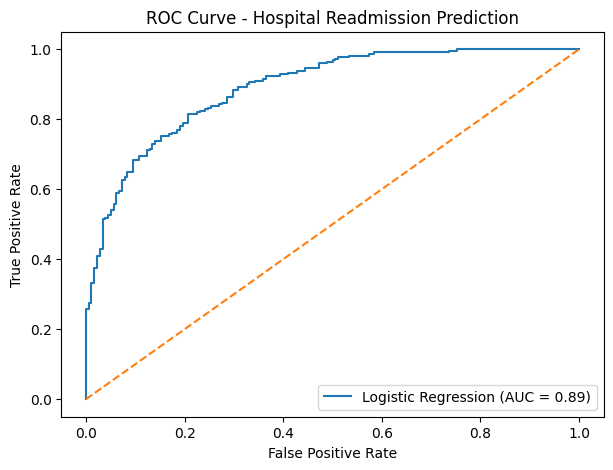

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


df = pd.read_csv("hospital_2000.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

df = df.drop("patient_id", axis=1)

X = df.drop("readmitted", axis=1)
y = df["readmitted"]

numerical_columns = [
    "age",
    "blood_pressure",
    "glucose",
    "previous_visits"
]

categorical_columns = [
    "gender",
    "diagnosis"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_columns
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "logistic_regression",
            LogisticRegression(
                C=1.0,
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining Records:", len(X_train))
print("Testing Records:", len(X_test))

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy, 4))

auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC:", round(auc, 4))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Hospital Readmission Prediction")

plt.legend()

plt.show()